In [15]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

## Data load

In [16]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

## Dataset overview

### Feature Preview

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Feature info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

None

### Feature missing values

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

### Feature distributions

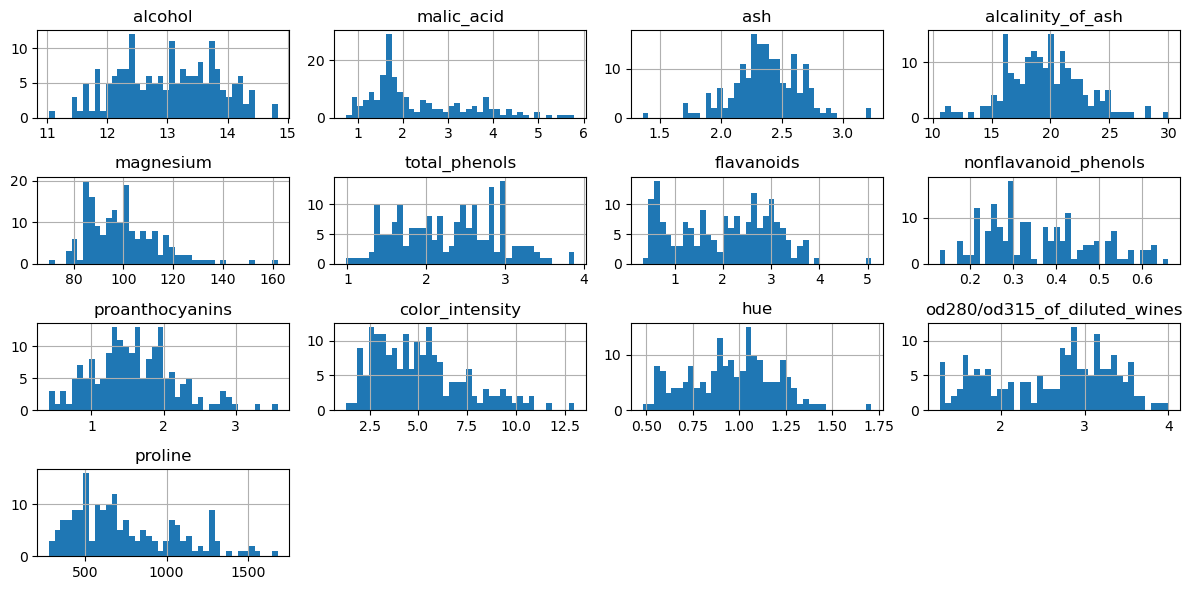

### Target Preview

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

### Target info

<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: target
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


None

### Target missing values

np.int64(0)

### Target Class Distribution

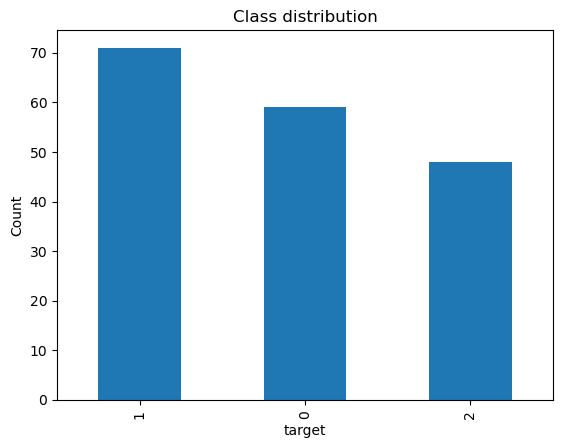

In [17]:
display(Markdown("### Feature Preview"))
display(X.head())
display(Markdown("### Feature info"))
display(X.info())
display(Markdown("### Feature missing values"))
display(X.isnull().sum())
display(Markdown("### Feature distributions"))
X.hist(figsize=(12,6), bins=40)
plt.tight_layout()
plt.show()

display(Markdown("### Target Preview"))
display(y.head())
display(Markdown("### Target info"))
display(y.info())
display(Markdown("### Target missing values"))
display(y.isnull().sum())
display(Markdown("### Target Class Distribution"))
y.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()


## Train data inspection

### Feature Preview

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
164,13.78,2.76,2.30,22.0,90.0,1.35,0.68,0.41,1.03,9.58,0.70,1.68,615.0
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0
145,13.16,3.57,2.15,21.0,102.0,1.50,0.55,0.43,1.30,4.00,0.60,1.68,830.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
149,13.08,3.90,2.36,21.5,113.0,1.41,1.39,0.34,1.14,9.40,0.57,1.33,550.0


### Feature info

<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, 164 to 135
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       142 non-null    float64
 1   malic_acid                    142 non-null    float64
 2   ash                           142 non-null    float64
 3   alcalinity_of_ash             142 non-null    float64
 4   magnesium                     142 non-null    float64
 5   total_phenols                 142 non-null    float64
 6   flavanoids                    142 non-null    float64
 7   nonflavanoid_phenols          142 non-null    float64
 8   proanthocyanins               142 non-null    float64
 9   color_intensity               142 non-null    float64
 10  hue                           142 non-null    float64
 11  od280/od315_of_diluted_wines  142 non-null    float64
 12  proline                       142 non-null    float64
dtypes: float

None

### Feature missing values

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

### Feature distributions

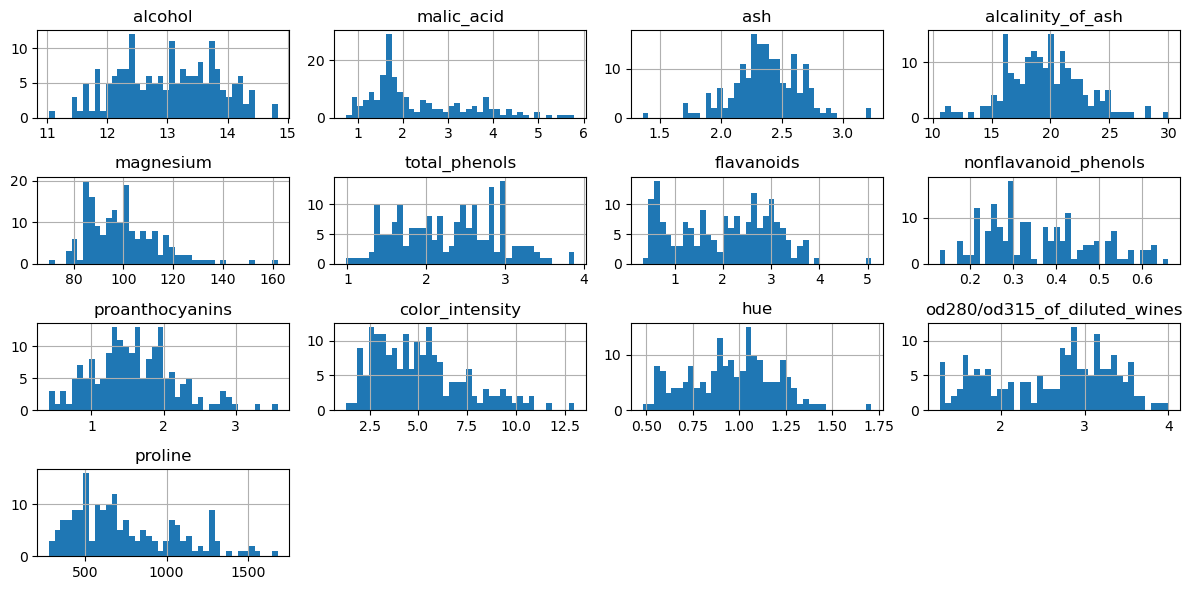

### Target Preview

164    2
73     1
145    2
4      0
149    2
Name: target, dtype: int64

### Target info

<class 'pandas.core.series.Series'>
Index: 142 entries, 164 to 135
Series name: target
Non-Null Count  Dtype
--------------  -----
142 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


None

### Target missing values

np.int64(0)

### Target Class Distribution

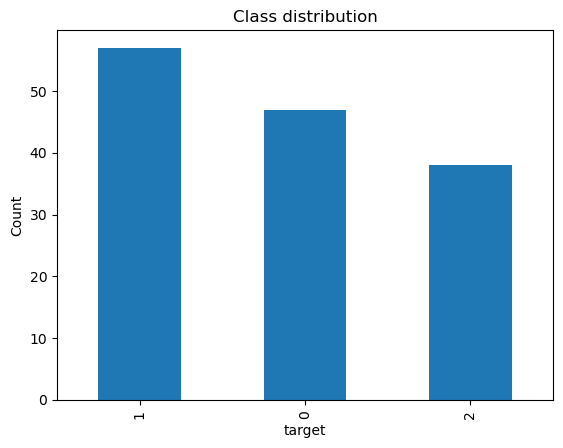

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

display(Markdown("### Feature Preview"))
display(X_train.head())
display(Markdown("### Feature info"))
display(X_train.info())
display(Markdown("### Feature missing values"))
display(X_train.isnull().sum())
display(Markdown("### Feature distributions"))
X.hist(figsize=(12,6), bins=40)
plt.tight_layout()
plt.show()

display(Markdown("### Target Preview"))
display(y_train.head())
display(Markdown("### Target info"))
display(y_train.info())
display(Markdown("### Target missing values"))
display(y_train.isnull().sum())
display(Markdown("### Target Class Distribution"))
y_train.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()


## Preprocessing and Model training

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid = [
    {
        "model__n_neighbors": [1,2,3,4,5,6]
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
best_model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


# Evaluation

Accuracy: 0.9166666666666666

Classification report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.79      0.88        14
           2       1.00      1.00      1.00        10

    accuracy                           0.92        36
   macro avg       0.93      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36

Confusion matrix:



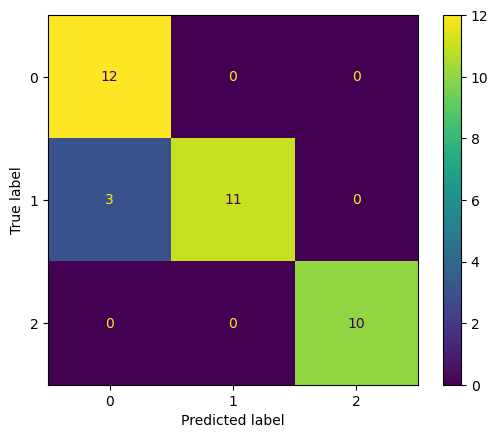

In [21]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print()
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print()